In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
workspace_root = str(Path.cwd().parent)
if workspace_root not in sys.path:
    sys.path.insert(0, workspace_root)

from utils.statevector_viz import plot_statevector_real_imag, get_data_amplitudes, print_statevector, plot_statevector_real_imag, plot_statevector_modulus_phase
from utils.statevector_viz import sample_measurement_counts, print_measurement_counts


from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram


# Encoding $f(x) = x^2$ via Matrix Product States

**Target state:**
$$|\psi\rangle = \frac{1}{\mathcal{N}} \sum_{x=0}^{2^n-1} x^2\,|x\rangle, \qquad \mathcal{N} = \sqrt{\sum_x x^4}$$

## MPS Structure: $\chi = 3$

Since $x = \sum_k s_k \cdot 2^{n-1-k}$, the square $x^2 = \left(\sum_k s_k \cdot p_k\right)^2$ is a **degree-2 polynomial** in the binary digits. The MPS needs three bond states to track the running partial sums:

- **State 0**: constant (1)
- **State 1**: linear running sum $\sigma = \sum_{j \leq k} s_j \cdot p_j$
- **State 2**: quadratic running sum $\sigma^2$

Define $p_k = 2^{n-1-k}$. The transfer matrices are:

$$A^{[k]0} = I_3, \qquad A^{[k]1} = \begin{pmatrix}1 & p_k & p_k^2 \\ 0 & 1 & 2p_k \\ 0 & 0 & 1\end{pmatrix}$$

The upper-triangular structure tracks: when bit $s_k = 1$ adds $p_k$ to the running sum $\sigma$, the new quadratic sum is $(\sigma + p_k)^2 = \sigma^2 + 2\sigma p_k + p_k^2$.

With left boundary $\ell = (1, 0, 0)/\mathcal{N}$ and right boundary $r = (0, 0, 1)^T$:

$$\ell\,\prod_k A^{[k]s_k}\,r = \frac{x^2}{\mathcal{N}}$$

The norm $\mathcal{N}^2 = \sum_x x^4$ is computed in $O(n)$ via $9\times9$ transfer matrix contraction.

In [2]:
import numpy as np
from scipy.linalg import null_space
from qiskit.circuit.library import UnitaryGate


# --- MPS infrastructure (shared with MatrixProductState2S notebook) ---

def mps_decompose(psi, n):
    """Decompose a normalised state vector into right-canonical MPS tensors."""
    tensors = [None] * n
    remaining = psi.copy()
    chi_R = 1
    for k in range(n - 1, 0, -1):
        d_left = remaining.size // (2 * chi_R)
        M = remaining.reshape(d_left, 2 * chi_R)
        U, S, Vh = np.linalg.svd(M, full_matrices=False)
        chi_L = int(np.sum(S > 1e-12))
        U, S, Vh = U[:, :chi_L], S[:chi_L], Vh[:chi_L, :]
        tensors[k] = Vh.reshape(chi_L, 2, chi_R)
        remaining = U @ np.diag(S)
        chi_R = chi_L
    tensors[0] = remaining.reshape(1, 2, chi_R)
    return tensors


def mps_tensor_to_unitary(A, dim_bond):
    """Extend a right-canonical MPS tensor to a unitary gate matrix."""
    chi_L, d, chi_R = A.shape
    dim_total = d * dim_bond
    V = np.zeros((dim_total, chi_L), dtype=complex)
    for aL in range(chi_L):
        for s in range(d):
            for aR in range(chi_R):
                V[s * dim_bond + aR, aL] = A[aL, s, aR]
    if chi_L < dim_total:
        N = null_space(V.conj().T)
        return np.hstack([V, N])
    return V.copy()


def right_canonicalize(tensors):
    """Bring MPS tensors into right-canonical form via right-to-left QR sweep."""
    n = len(tensors)
    rc = [t.copy().astype(complex) for t in tensors]
    for k in range(n - 1, 0, -1):
        chi_L, d, chi_R = rc[k].shape
        M = rc[k].reshape(chi_L, d * chi_R)
        Q_qr, R_qr = np.linalg.qr(M.conj().T)
        L = R_qr.conj().T
        Q = Q_qr.conj().T
        chi_new = Q.shape[0]
        rc[k] = Q.reshape(chi_new, d, chi_R)
        pL, pd, pR = rc[k - 1].shape
        prev_mat = rc[k - 1].reshape(pL * pd, pR)
        rc[k - 1] = (prev_mat @ L).reshape(pL, pd, chi_new)
    return rc


def mps_circuit_from_tensors(tensors, n):
    """Build a quantum circuit from right-canonical MPS tensors."""
    max_chi = max(max(t.shape[0], t.shape[2]) for t in tensors)
    n_bond = int(np.ceil(np.log2(max(max_chi, 2))))
    dim_bond = 2 ** n_bond
    qc = QuantumCircuit(n + n_bond)
    bond_qubits = list(range(n, n + n_bond))
    for k, A in enumerate(tensors):
        U = mps_tensor_to_unitary(A, dim_bond)
        phys_qubit = n - 1 - k
        gate = UnitaryGate(U, label=f'MPS[{k}]')
        qc.append(gate, bond_qubits + [phys_qubit])
    return qc


# --- Analytical MPS for f(x) = x² ---

def _norm_sq_quadratic(n):
    """Compute sum_{x=0}^{2^n-1} x^4  in O(n)
    via 9x9 transfer matrix contraction.

    Transfer matrices:  A^0 = I_3,  A^1 = [[1, p_k, p_k²], [0, 1, 2p_k], [0, 0, 1]]
    Left boundary: (1, 0, 0),  Right boundary: (0, 0, 1)
    """
    l = np.array([1.0, 0.0, 0.0])
    r = np.array([0.0, 0.0, 1.0])
    v = np.kron(l, l)  # 9-dim

    for k in range(n):
        p_k = 2.0 ** (n - 1 - k)
        N_k = np.array([
            [1.0,  p_k,  p_k * p_k],
            [0.0,  1.0,  2.0 * p_k],
            [0.0,  0.0,        1.0],
        ])
        T_k = np.eye(9) + np.kron(N_k, N_k)
        v = v @ T_k

    return v @ np.kron(r, r)


def analytical_mps_quadratic(n):
    """Construct MPS tensors for |psi> = (1/N) sum_x x² |x> analytically.

    Bond dimension is exactly 3 for any n.
    Cost: O(n) — no exponential state vector needed.

    Transfer matrices:
        A^{[k]0} = I_3
        A^{[k]1} = [[1, p_k, p_k²], [0, 1, 2*p_k], [0, 0, 1]]

    Left boundary: (1, 0, 0) / N
    Right boundary: (0, 0, 1)^T
    """
    norm = np.sqrt(_norm_sq_quadratic(n))

    if n == 1:
        A = np.zeros((1, 2, 1))
        A[0, 0, 0] = 0.0      # f(0) = 0
        A[0, 1, 0] = 1.0 / norm  # f(1) = 1
        return [A]

    tensors = []
    for k in range(n):
        p_k = 2.0 ** (n - 1 - k)

        if k == 0:
            # Left boundary: absorb (1/N, 0, 0)
            A = np.zeros((1, 2, 3))
            A[0, 0, :] = [1.0 / norm, 0.0, 0.0]
            A[0, 1, :] = [1.0 / norm,
                          p_k / norm,
                          p_k * p_k / norm]
        elif k == n - 1:
            # Right boundary: absorb (0, 0, 1)^T
            A = np.zeros((3, 2, 1))
            A[:, 0, 0] = [0.0, 0.0, 1.0]
            A[:, 1, 0] = [p_k * p_k,
                          2.0 * p_k,
                          1.0]
        else:
            # Interior: upper-triangular for s=1, identity for s=0
            A = np.zeros((3, 2, 3))
            A[:, 0, :] = np.eye(3)
            A[:, 1, :] = [[1.0, p_k,       p_k * p_k],
                          [0.0,  1.0,      2.0 * p_k],
                          [0.0,  0.0,            1.0]]

        tensors.append(A)
    return tensors


print("Functions defined: _norm_sq_quadratic, analytical_mps_quadratic")
print("MPS infrastructure: mps_decompose, right_canonicalize, mps_circuit_from_tensors")


Functions defined: _norm_sq_quadratic, analytical_mps_quadratic
MPS infrastructure: mps_decompose, right_canonicalize, mps_circuit_from_tensors


Analytical MPS for f(x) = x²  (n=8)
Tensors (right-canonical):
  site 0:  shape (1, 2, 3)  (χ_L=1, χ_R=3)  isometry err = 2.22e-16
  site 1:  shape (3, 2, 3)  (χ_L=3, χ_R=3)  isometry err = 2.36e-16
  site 2:  shape (3, 2, 3)  (χ_L=3, χ_R=3)  isometry err = 4.44e-16
  site 3:  shape (3, 2, 3)  (χ_L=3, χ_R=3)  isometry err = 2.22e-16
  site 4:  shape (3, 2, 3)  (χ_L=3, χ_R=3)  isometry err = 2.22e-16
  site 5:  shape (3, 2, 3)  (χ_L=3, χ_R=3)  isometry err = 4.44e-16
  site 6:  shape (3, 2, 2)  (χ_L=3, χ_R=2)  isometry err = 4.95e-16
  site 7:  shape (2, 2, 1)  (χ_L=2, χ_R=1)  isometry err = 0.00e+00

Circuit: 10 qubits, 146 CX gates

Fidelity vs exact target: 1.0000000000
Norm check:  analytical = 466648.084003,  exact = 466648.084003,  diff = 0.00e+00
Statevector amplitudes (|basis⟩ : amplitude):
  |00000001⟩ : 0.0000+0.0000j  (prob = 0.0000)
  |00000010⟩ : 0.0000+0.0000j  (prob = 0.0000)
  |00000011⟩ : 0.0000+0.0000j  (prob = 0.0000)
  |00000100⟩ : 0.0000+0.0000j  (prob = 0.0000)
  |

c:\Users\sorin\anaconda3\envs\qiskit21\Lib\site-packages\qiskit\visualization\circuit\matplotlib.py:270: UserWarning: Style JSON file 'iqx.json' not found in any of these locations: c:\Users\sorin\anaconda3\envs\qiskit21\Lib\site-packages\qiskit\visualization\circuit\styles\iqx.json, iqx.json. Will use default style.
  self._style, def_font_ratio = load_style(


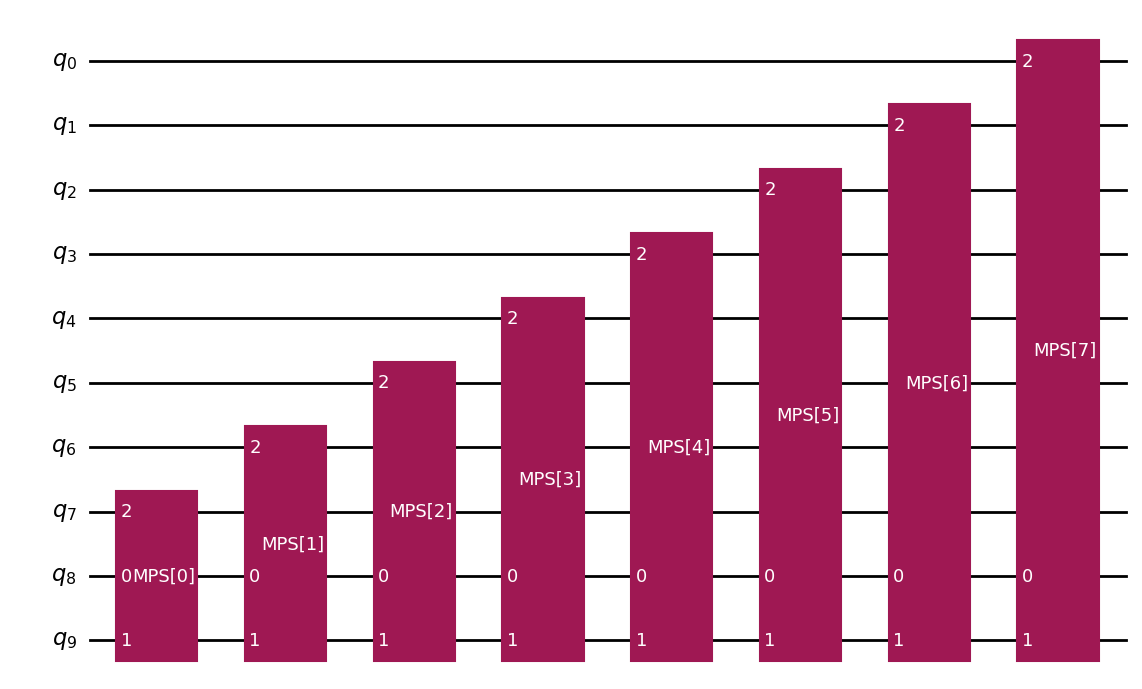

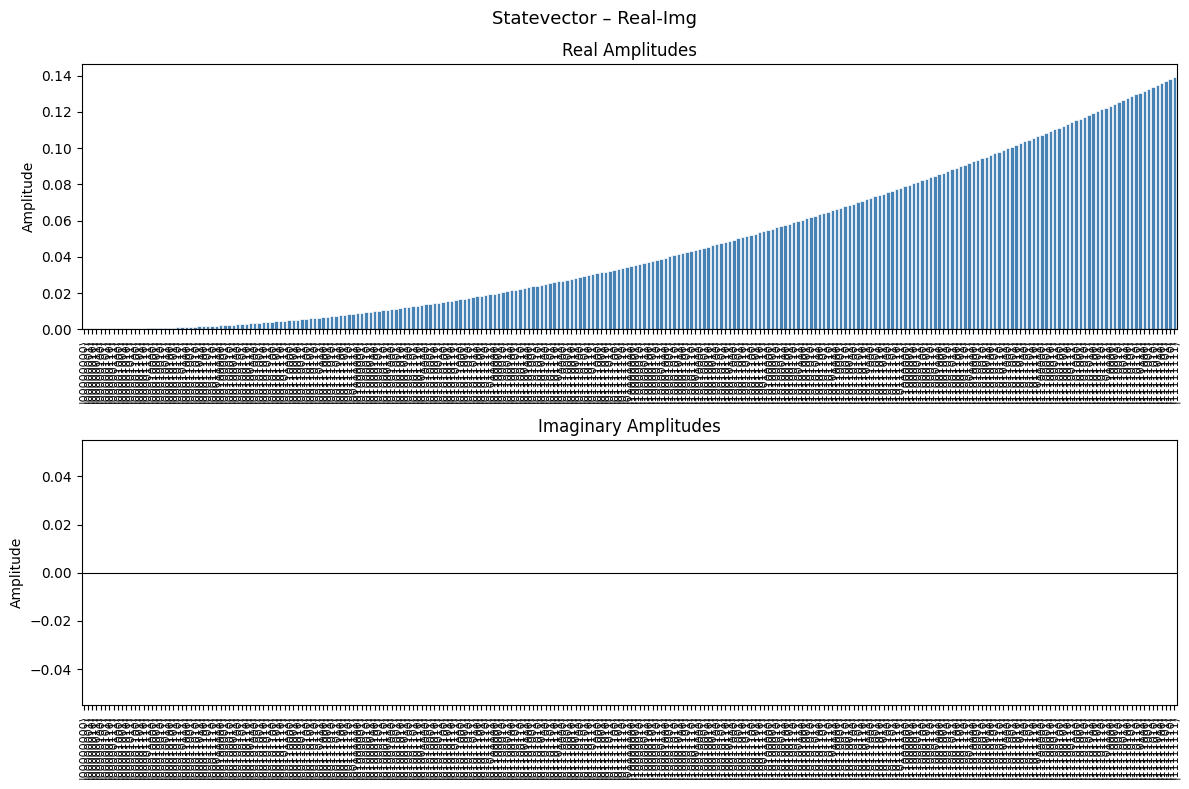

In [ ]:
# --- Verify analytical MPS for x² against exact state ---
n_qubits = 8

# Analytical MPS construction (O(n), no 2^n vector)
raw_q = analytical_mps_quadratic(n_qubits)
rc_q  = right_canonicalize(raw_q)

print(f"Analytical MPS for f(x) = x²  (n={n_qubits})")
print("Tensors (right-canonical):")
for k, A in enumerate(rc_q):
    M = A.reshape(A.shape[0], -1)
    err = np.max(np.abs(M @ M.conj().T - np.eye(A.shape[0])))
    print(f"  site {k}:  shape {A.shape}  (χ_L={A.shape[0]}, χ_R={A.shape[2]})  "
          f"isometry err = {err:.2e}")

# Build circuit
qc_q = mps_circuit_from_tensors(rc_q, n_qubits)
qc_q_t = transpile(qc_q, basis_gates=['u', 'cx'], optimization_level=2)
print(f"\nCircuit: {qc_q_t.num_qubits} qubits, "
      f"{qc_q_t.count_ops().get('cx', 0)} CX gates")

# Compare against exact target
dim = 2 ** n_qubits
target_exact = np.array([x * x for x in range(dim)], dtype=complex)
target_exact /= np.linalg.norm(target_exact)

data_amps = get_data_amplitudes(qc_q, n_qubits)
fidelity = abs(np.vdot(target_exact, data_amps)) ** 2
print(f"\nFidelity vs exact target: {fidelity:.10f}")

# Norm check
norm_analytical = np.sqrt(_norm_sq_quadratic(n_qubits))
norm_exact = np.linalg.norm([x * x for x in range(dim)])
print(f"Norm check:  analytical = {norm_analytical:.6f},  exact = {norm_exact:.6f},  "
      f"diff = {abs(norm_analytical - norm_exact):.2e}")

# Plot
print_statevector(data_amps, n_qubits)
fig = plot_statevector_real_imag(data_amps, n_qubits)

# Measurement histogram
shots = 4096
counts = sample_measurement_counts(qc_q, n_qubits, shots=shots)
print_measurement_counts(counts, shots)
plot_histogram(counts, figsize=(12, 5), bar_labels=True)


In [4]:
# --- Scale to large n ---
import time

print(f"f(x) = x²  —  analytical MPS (χ=3)\n")

for n_large in [10, 20, 50, 100, 200]:
    t0 = time.perf_counter()
    raw = analytical_mps_quadratic(n_large)
    rc  = right_canonicalize(raw)
    qc_large = mps_circuit_from_tensors(rc, n_large)
    qc_large_t = transpile(qc_large, basis_gates=['u', 'cx'], optimization_level=2)
    dt = time.perf_counter() - t0

    cx_count = qc_large_t.count_ops().get('cx', 0)
    max_chi = max(max(t.shape[0], t.shape[2]) for t in rc)
    print(f"n={n_large:>3d}:  {qc_large_t.num_qubits:>4d} qubits,  "
          f"{cx_count:>4d} CX gates,  max χ={max_chi},  built in {dt:.3f}s")


f(x) = x²  —  analytical MPS (χ=3)

n= 10:    12 qubits,   182 CX gates,  max χ=3,  built in 0.756s
n= 20:    22 qubits,   362 CX gates,  max χ=3,  built in 0.844s
n= 50:    52 qubits,   902 CX gates,  max χ=3,  built in 2.189s
n=100:   102 qubits,  1802 CX gates,  max χ=3,  built in 4.531s
n=200:   202 qubits,  3602 CX gates,  max χ=3,  built in 8.478s


Fidelity of U†|0⟩ with sqrt(x) target: 0.8163309597
  → No match.

First 16 amplitudes of U†|0⟩ vs sqrt(x)/N:
  x= 0:  U†|0⟩ = +0.000000   sqrt(x)/N = +0.000000
  x= 1:  U†|0⟩ = +0.000002   sqrt(x)/N = +0.005535
  x= 2:  U†|0⟩ = +0.000009   sqrt(x)/N = +0.007828
  x= 3:  U†|0⟩ = +0.000019   sqrt(x)/N = +0.009587
  x= 4:  U†|0⟩ = +0.000034   sqrt(x)/N = +0.011070
  x= 5:  U†|0⟩ = +0.000054   sqrt(x)/N = +0.012377
  x= 6:  U†|0⟩ = +0.000077   sqrt(x)/N = +0.013558
  x= 7:  U†|0⟩ = +0.000105   sqrt(x)/N = +0.014644
  x= 8:  U†|0⟩ = +0.000137   sqrt(x)/N = +0.015656
  x= 9:  U†|0⟩ = +0.000174   sqrt(x)/N = +0.016605
  x=10:  U†|0⟩ = +0.000214   sqrt(x)/N = +0.017504
  x=11:  U†|0⟩ = +0.000259   sqrt(x)/N = +0.018358
  x=12:  U†|0⟩ = +0.000309   sqrt(x)/N = +0.019174
  x=13:  U†|0⟩ = +0.000362   sqrt(x)/N = +0.019957
  x=14:  U†|0⟩ = +0.000420   sqrt(x)/N = +0.020710
  x=15:  U†|0⟩ = +0.000482   sqrt(x)/N = +0.021437


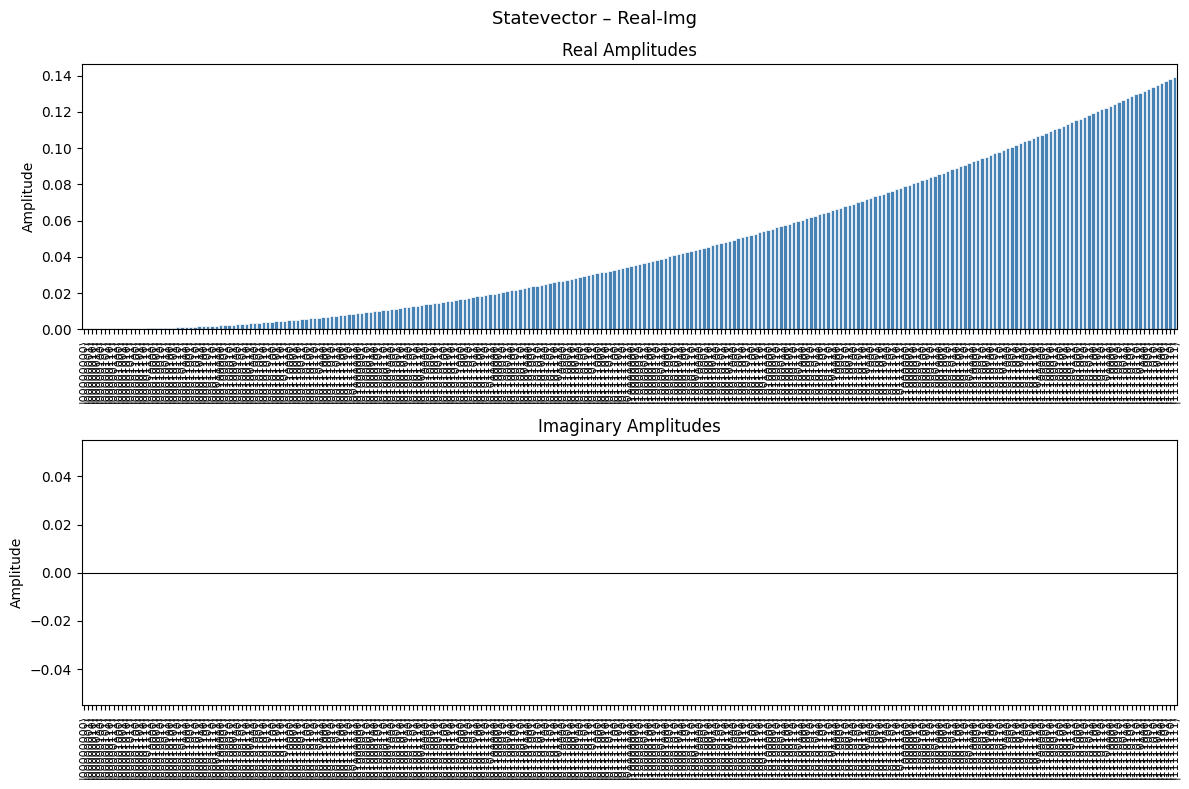

In [ ]:
# --- Does U†|0⟩ give sqrt(x)? ---
n_qubits = 8
dim = 2 ** n_qubits

# Build x² circuit and take its inverse
raw_q = analytical_mps_quadratic(n_qubits)
rc_q  = right_canonicalize(raw_q)
qc_q  = mps_circuit_from_tensors(rc_q, n_qubits)
qc_inv = qc_q.inverse()

# Get amplitudes of U†|0⟩
amps_inv = get_data_amplitudes(qc_inv, n_qubits)

# Compare against the actual sqrt target
target_sqrt = np.array([np.sqrt(x) for x in range(dim)], dtype=complex)
target_sqrt /= np.linalg.norm(target_sqrt)

fidelity_sqrt = abs(np.vdot(target_sqrt, amps_inv)) ** 2
print(f"Fidelity of U†|0⟩ with sqrt(x) target: {fidelity_sqrt:.10f}")
print(f"  → {'Match!' if fidelity_sqrt > 0.999 else 'No match.'}\n")

# What does U†|0⟩ actually look like?
print("First 16 amplitudes of U†|0⟩ vs sqrt(x)/N:")
for x in range(16):
    print(f"  x={x:>2d}:  U†|0⟩ = {amps_inv[x].real:>+.6f}   "
          f"sqrt(x)/N = {target_sqrt[x].real:>+.6f}")

fig = plot_statevector_real_imag(amps_inv, n_qubits)
